# Bi-Cross-Validation Evaluation — Reaching

Compare BCV generalization performance (pseudo-R²) for two mSCA configurations:

- **nonlinear-nonlinear**: mSCA with nonlinear decoder → BCV decoder = `MLPRegressor(loss='poisson')`
- **nonlinear-linear**: mSCA with linear decoder → BCV decoder = Poisson GLM (`PoissonRegressor`)

In [1]:
import os, sys, importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

import msca, msca.models, msca.architectures, msca.utils, msca.evaluations
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca.evaluations)
importlib.reload(msca)
from msca import mSCA
from msca.evaluations import evaluate_trial_average

## Config

In [2]:
LOSS_FUNC = "poisson"   # Poisson spike count data

# ── nonlinear-nonlinear: mSCA trained with nonlinear decoder ─────────────────
PATH_NN = "./results/bi-cross-validation/nonlinear-nonlinear/"
KWARGS_NN = dict(
    n_components=20, loss_func="Poisson", n_epochs=5000, post_hoc_epoch=-1,
    linear=False, lam_region=0.0, decoder_type="nonlinear",
    decoder_hidden_size=40, decoder_activation="tanh",
    cd_rate=0.5, cd_mode="both", filter_len=41,
    init="unique", decoder_init_mode="pca",
    sparsity_warmup_epochs=1000, balance_interval=1000,
)

# ── nonlinear-linear: mSCA trained with linear decoder ──────────────────────
PATH_NL = "./results/bi-cross-validation/nonlinear-linear/"
KWARGS_NL = dict(
    n_components=20, loss_func="Poisson", n_epochs=5000, post_hoc_epoch=-1,
    linear=False, lam_region=0.0, decoder_type="linear",
    decoder_hidden_size=40, decoder_activation="tanh",
    cd_rate=0.5, cd_mode="both", filter_len=41,
    init="unique", decoder_init_mode="pca",
    sparsity_warmup_epochs=1000, balance_interval=1000,
)

## 1. Load reaching data

In [9]:
import h5py

def load_hdf5_to_dict(filename):
    """
    Recursive loader for the HDF5 files.
    """

    def recursive_load(group):
        data = {}
        for key, item in group.items():
            if isinstance(item, h5py.Group):
                data[key] = recursive_load(item)
            else:
                data[key] = item[()]
        return data

    with h5py.File(filename, "r") as h5file:
        return recursive_load(h5file)
    


    
data_dir = "./data"
# Load preprocessed dataset
training_dataset = load_hdf5_to_dict(
    os.path.join(data_dir, "arena_training_bin_size=10.h5")
)

# Container for mSCA style input
X = {k: [] for k in ["cortex", "striatum"]}

# Split off only the striatal or cortical data
for brain_region in X.keys():
    for i, (k, v) in enumerate(training_dataset.items()):
        X[brain_region] += [v_i for v_i in v[brain_region]]

## 2. Load neuron splits

In [10]:
# Neuron splits are shared across both experiments
train_idxs = torch.load(os.path.join(PATH_NL, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(PATH_NL, "n_test_splits.pt"),  weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of neuron folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}: train={[len(t) for t in train_idxs[k]]}, test={[len(t) for t in test_idxs[k]]}")

Number of neuron folds: 5
  cortex: train=[64, 65, 65, 65, 65], test=[17, 16, 16, 16, 16]
  striatum: train=[118, 118, 118, 119, 119], test=[30, 30, 30, 29, 29]


## 3. Evaluate both conditions

For each of the 5 neuron folds, load each trained mSCA model and run `evaluate_trial_average` with the matching BCV decoder:
- **nonlinear-nonlinear** → `decoder_type="nonlinear"` (MLPRegressor, loss='poisson')
- **nonlinear-linear** → `decoder_type="linear"` (Poisson GLM)

In [11]:
results = {
    "nonlinear-nonlinear": [],
    "nonlinear-linear":    [],
}

for i in range(n_folds):
    print(f"\n=== Neuron fold {i} ===")

    X_train = {k: [trial[:, train_idxs[k][i]] for trial in v] for k, v in X.items()}
    X_val   = {k: [trial[:, test_idxs[k][i]]  for trial in v] for k, v in X.items()}

    # --- nonlinear-nonlinear ---
    model_nn = mSCA(**KWARGS_NN)
    model_nn.load(os.path.join(PATH_NN, f"msca_split_{i}.pt"), X_train)
    perfs_nn = evaluate_trial_average(
        model_nn, X_train, X_val,
        loss_func=LOSS_FUNC, decoder_type="nonlinear", n_splits=5,
    )
    results["nonlinear-nonlinear"].append(float(np.mean(perfs_nn)))

    # --- nonlinear-linear ---
    model_nl = mSCA(**KWARGS_NL)
    model_nl.load(os.path.join(PATH_NL, f"msca_split_{i}.pt"), X_train)
    perfs_nl = evaluate_trial_average(
        model_nl, X_train, X_val,
        loss_func=LOSS_FUNC, decoder_type="linear", n_splits=5,
    )
    results["nonlinear-linear"].append(float(np.mean(perfs_nl)))

    print(f"  nonlinear-nonlinear: {results['nonlinear-nonlinear'][-1]:.4f}")
    print(f"  nonlinear-linear:    {results['nonlinear-linear'][-1]:.4f}")

print("\n=== Summary ===")
for cond, vals in results.items():
    print(f"  {cond}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")


=== Neuron fold 0 ===
Using region-weights = {'cortex': 1.0060115147665178, 'striatum': 0.994059903192824}
Using lam_sparse = adaptive
Using lam_orthog = 2716.4927357895767
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: nonlinear
hidden_layer_sizes: (155,)


/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_base.py:215: RuntimeWarning: invalid value encountered in divide
  xlogy(y_true, y_true / y_pred) - y_true + y_pred, weights=sample_weight, axis=0
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mSCA/lib/python3.11/site-p

Using region-weights = {'cortex': 1.0060115147665178, 'striatum': 0.994059903192824}
Using lam_sparse = adaptive
Using lam_orthog = 2716.4927357895767
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  nonlinear-nonlinear: 0.0978
  nonlinear-linear:    0.0004

=== Neuron fold 1 ===
Using region-weights = {'cortex': 0.9841824183666572, 'striatum': 1.0163343205301647}
Using lam_sparse = adaptive
Using lam_orthog = 3043.1272873924836
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: nonlinear
hidden_layer_sizes: (155,)


...

  nonlinear-nonlinear: 0.0946
  nonlinear-linear:    0.0045

=== Neuron fold 4 ===
Using region-weights = {'cortex': 1.0253197179553262, 'striatum': 0.9759006590749376}
Using lam_sparse = adaptive
Using lam_orthog = 3016.704133584724
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: nonlinear
hidden_layer_sizes: (155,)


/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_base.py:215: RuntimeWarning: invalid value encountered in divide
  xlogy(y_true, y_true / y_pred) - y_true + y_pred, weights=sample_weight, axis=0
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mSCA/lib/python3.11/site-p

Using region-weights = {'cortex': 1.0253197179553262, 'striatum': 0.9759006590749376}
Using lam_sparse = adaptive
Using lam_orthog = 3016.704133584724
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  nonlinear-nonlinear: 0.1058
  nonlinear-linear:    0.0048

=== Summary ===
  nonlinear-nonlinear: 0.1037 +/- 0.0064
  nonlinear-linear: -0.0413 +/- 0.0885


## nonlinear linear only 

In [5]:
results = {
    "nonlinear-linear":    [],
}

for i in range(n_folds):
    print(f"\n=== Neuron fold {i} ===")

    X_train = {k: [trial[:, train_idxs[k][i]] for trial in v] for k, v in X.items()}
    X_val   = {k: [trial[:, test_idxs[k][i]]  for trial in v] for k, v in X.items()}

   
    # --- nonlinear-linear ---
    model_nl = mSCA(**KWARGS_NL)
    model_nl.load(os.path.join(PATH_NL, f"msca_split_{i}.pt"), X_train)
    perfs_nl = evaluate_trial_average(
        model_nl, X_train, X_val,
        loss_func=LOSS_FUNC, decoder_type="linear", n_splits=5,
    )
    results["nonlinear-linear"].append(float(np.mean(perfs_nl)))

   
    print(f"  nonlinear-linear:    {results['nonlinear-linear'][-1]:.4f}")




=== Neuron fold 0 ===
Using region-weights = {'M1': 1.4623658516159581, 'PMd': 0.7597764660707902}
Using lam_sparse = adaptive
Using lam_orthog = 3021.3815789473683
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/linear_model/_glm/_newton_solver.py:501: ConvergenceWarning: The inner solver of NewtonCholeskySolver detected a pointwise hessian with many negative values at iteration #1. It will now resort to lbfgs instead.
  warnings.warn(


  nonlinear-linear:    0.0332

=== Neuron fold 1 ===
Using region-weights = {'M1': 1.4681614740070594, 'PMd': 0.7582213883860629}
Using lam_sparse = adaptive
Using lam_orthog = 3062.9624999999996
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  nonlinear-linear:    0.0333

=== Neuron fold 2 ===
Using region-weights = {'M1': 1.4582136306828326, 'PMd': 0.7609021537523396}
Using lam_sparse = adaptive
Using lam_orthog = 3014.435526315789
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)


...

  nonlinear-linear:    0.0180

=== Neuron fold 3 ===
Using region-weights = {'M1': 1.4047128446802117, 'PMd': 0.776330773316662}
Using lam_sparse = adaptive
Using lam_orthog = 3066.8709703947366
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  nonlinear-linear:    0.0250

=== Neuron fold 4 ===


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)
[2026-07-09 21:12:51,617] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-07-09 21:12:51,617] torch._dynamo.convert_frame: [WARNING]    function: 'forward' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:124)
[2026-07-09 21:12:51,617] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-07-09 21:12:51,617] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-07-09 21:12:51,617] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/comp

Using region-weights = {'M1': 1.370848106623441, 'PMd': 0.7870764695916153}
Using lam_sparse = adaptive
Using lam_orthog = 3129.6428453947365
Using lam_region = 0.0
inside evaluate_trial_average
loss_func: poisson
decoder_type: linear
hidden_layer_sizes: (155,)
  nonlinear-linear:    0.0273


## 4. Comparison plot

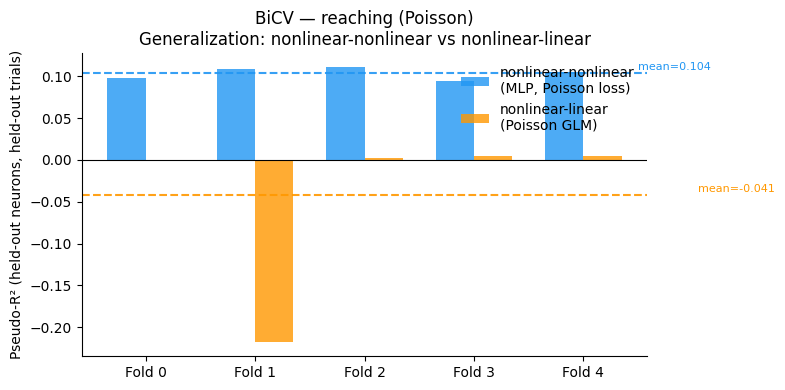

In [12]:
colors = {"nonlinear-nonlinear": "#2196F3", "nonlinear-linear": "#FF9800"}
labels = {"nonlinear-nonlinear": "nonlinear-nonlinear\n(MLP, Poisson loss)",
          "nonlinear-linear":    "nonlinear-linear\n(Poisson GLM)"}

x = np.arange(n_folds)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))

for k, (cond, vals) in enumerate(results.items()):
    offset = (k - 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=labels[cond],
                  color=colors[cond], alpha=0.8)
    ax.axhline(np.mean(vals), color=colors[cond], lw=1.5, ls="--", alpha=0.9)

# Annotate means on the right
for k, (cond, vals) in enumerate(results.items()):
    ax.text(n_folds - 0.5 + k * 0.55, np.mean(vals) + 0.001,
            f"mean={np.mean(vals):.3f}", color=colors[cond], fontsize=8, va='bottom')

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(n_folds)])
ax.set_ylabel("Pseudo-R² (held-out neurons, held-out trials)")
ax.set_title("BiCV — reaching (Poisson)\nGeneralization: nonlinear-nonlinear vs nonlinear-linear")
ax.axhline(0, color="black", lw=0.8)
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PATH_NN, "bcv_comparison_nn_vs_nl.pdf"), bbox_inches="tight")
plt.show()

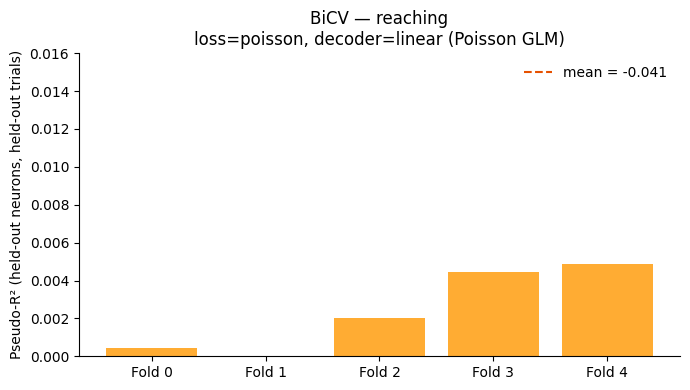

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

vals = results["nonlinear-linear"]
x = np.arange(n_folds)

ax.bar(x, vals, color="#FF9800", alpha=0.8)
ax.axhline(np.mean(vals), color="#E65100", lw=1.5, ls="--", label=f"mean = {np.mean(vals):.3f}")

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(n_folds)])
ax.set_ylabel("Pseudo-R² (held-out neurons, held-out trials)")
ax.set_title("BiCV — reaching\nloss=poisson, decoder=linear (Poisson GLM)")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PATH_NL, "bcv_nonlinear_linear.pdf"), bbox_inches="tight")
plt.show()


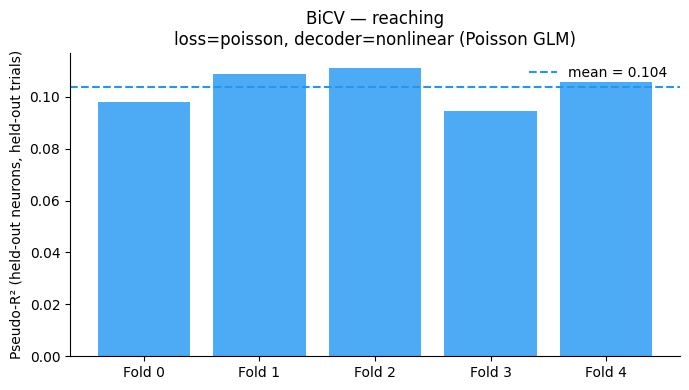

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

vals = results["nonlinear-nonlinear"]
x = np.arange(n_folds)

ax.bar(x, vals, color= "#2196F3", alpha=0.8)
ax.axhline(np.mean(vals), color= "#2196F3", lw=1.5, ls="--", label=f"mean = {np.mean(vals):.3f}")

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(n_folds)])
ax.set_ylabel("Pseudo-R² (held-out neurons, held-out trials)")
ax.set_title("BiCV — reaching\nloss=poisson, decoder=nonlinear (Poisson GLM)")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PATH_NL, "bcv_nonlinear_nonlinear.pdf"), bbox_inches="tight")
plt.show()
